In [5]:
import torch
import torch.nn as nn
from torch.nn.utils import spectral_norm # Import spectral_norm
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision.utils import save_image
import os
from torchsummary import summary
import csv
# ====================
# Config
# ====================
latent_dim = 100
img_size = 28
channels = 1
batch_size = 64
epochs = 50
lr = 0.0002
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs("images_sngan", exist_ok=True)

# ====================
# Data Loader
# ====================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

dataloader = DataLoader(
    datasets.MNIST('.', train=True, download=True, transform=transform),
    batch_size=batch_size, shuffle=True
)

# ====================
# Models (Generator is the same)
# ====================
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Linear(512, img_size * img_size),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.model(z)
        return img.view(z.size(0), 1, img_size, img_size)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            # Apply spectral_norm to each linear layer
            spectral_norm(nn.Linear(img_size * img_size, 512)),
            nn.LeakyReLU(0.2, inplace=True),
            spectral_norm(nn.Linear(512, 256)),
            nn.LeakyReLU(0.2, inplace=True),
            spectral_norm(nn.Linear(256, 1)),
            nn.Sigmoid()
        )

    def forward(self, img):
        img_flat = img.view(img.size(0), -1)
        return self.model(img_flat)

# ====================
# Initialize models and loss
# ====================
generator = Generator().to(device)
discriminator = Discriminator().to(device)



In [6]:
print("------------------------------------------------------------")
print("                    SNGAN Generator Summary")
print("------------------------------------------------------------")
summary(generator, (latent_dim,))

------------------------------------------------------------
                    SNGAN Generator Summary
------------------------------------------------------------
Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 784]                 --
|    └─Linear: 2-1                       [-1, 128]                 12,928
|    └─ReLU: 2-2                         [-1, 128]                 --
|    └─Linear: 2-3                       [-1, 256]                 33,024
|    └─BatchNorm1d: 2-4                  [-1, 256]                 512
|    └─ReLU: 2-5                         [-1, 256]                 --
|    └─Linear: 2-6                       [-1, 512]                 131,584
|    └─BatchNorm1d: 2-7                  [-1, 512]                 1,024
|    └─ReLU: 2-8                         [-1, 512]                 --
|    └─Linear: 2-9                       [-1, 784]                 402,192
|    └─Tanh: 2-10                    

Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 784]                 --
|    └─Linear: 2-1                       [-1, 128]                 12,928
|    └─ReLU: 2-2                         [-1, 128]                 --
|    └─Linear: 2-3                       [-1, 256]                 33,024
|    └─BatchNorm1d: 2-4                  [-1, 256]                 512
|    └─ReLU: 2-5                         [-1, 256]                 --
|    └─Linear: 2-6                       [-1, 512]                 131,584
|    └─BatchNorm1d: 2-7                  [-1, 512]                 1,024
|    └─ReLU: 2-8                         [-1, 512]                 --
|    └─Linear: 2-9                       [-1, 784]                 402,192
|    └─Tanh: 2-10                        [-1, 784]                 --
Total params: 581,264
Trainable params: 581,264
Non-trainable params: 0
Total mult-adds (M): 1.16
Input size (MB): 0.00
Forward/backw

In [7]:
# --- Print Discriminator Summary ---
# Input shape is the 2D image
print("\n\n------------------------------------------------------------")
print("                 SNGAN Discriminator Summary")
print("------------------------------------------------------------")
summary(discriminator, (channels, img_size, img_size))



------------------------------------------------------------
                 SNGAN Discriminator Summary
------------------------------------------------------------
Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 1]                   --
|    └─Linear: 2-1                       [-1, 512]                 401,920
|    └─LeakyReLU: 2-2                    [-1, 512]                 --
|    └─Linear: 2-3                       [-1, 256]                 131,328
|    └─LeakyReLU: 2-4                    [-1, 256]                 --
|    └─Linear: 2-5                       [-1, 1]                   257
|    └─Sigmoid: 2-6                      [-1, 1]                   --
Total params: 533,505
Trainable params: 533,505
Non-trainable params: 0
Total mult-adds (M): 1.07
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 2.04
Estimated Total Size (MB): 2.04


Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 1]                   --
|    └─Linear: 2-1                       [-1, 512]                 401,920
|    └─LeakyReLU: 2-2                    [-1, 512]                 --
|    └─Linear: 2-3                       [-1, 256]                 131,328
|    └─LeakyReLU: 2-4                    [-1, 256]                 --
|    └─Linear: 2-5                       [-1, 1]                   257
|    └─Sigmoid: 2-6                      [-1, 1]                   --
Total params: 533,505
Trainable params: 533,505
Non-trainable params: 0
Total mult-adds (M): 1.07
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 2.04
Estimated Total Size (MB): 2.04

In [8]:
# ====================
# Initialization
# ====================
optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))
criterion = nn.BCELoss()

# --- Setup for CSV Logging ---
loss_file_path = "sngan.csv"
with open(loss_file_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(["Epoch", "Discriminator_Loss", "Generator_Loss"])

# ====================
# Training Loop
# ====================
print("Starting SNGAN Training...")
for epoch in range(epochs):
    for i, (imgs, _) in enumerate(dataloader):
        real_imgs = imgs.to(device)
        
        real_labels = torch.ones(imgs.size(0), 1, device=device)
        fake_labels = torch.zeros(imgs.size(0), 1, device=device)

        # --- Train Discriminator ---
        optimizer_D.zero_grad()
        real_output = discriminator(real_imgs)
        loss_D_real = criterion(real_output, real_labels)
        z = torch.randn(imgs.size(0), latent_dim, device=device)
        fake_imgs = generator(z)
        fake_output = discriminator(fake_imgs.detach())
        loss_D_fake = criterion(fake_output, fake_labels)
        loss_D = (loss_D_real + loss_D_fake) / 2
        loss_D.backward()
        optimizer_D.step()

        # --- Train Generator ---
        optimizer_G.zero_grad()
        gen_output = discriminator(fake_imgs)
        loss_G = criterion(gen_output, real_labels)
        loss_G.backward()
        optimizer_G.step()
        
    # --- End of Epoch ---
    # Log results, save images, and write to CSV once per epoch
    print(f"[Epoch {epoch+1}/{epochs}] D loss: {loss_D.item():.4f} | G loss: {loss_G.item():.4f}")
    
    # Save a batch of generated images
    save_image(fake_imgs.data[:25], f"images_sngan/{epoch+1}.png", nrow=5, normalize=True)
    
    # Write the epoch's losses to the CSV file
    with open(loss_file_path, 'a', newline='') as f:
        csv.writer(f).writerow([epoch + 1, loss_D.item(), loss_G.item()])

print(f"Training Complete — SNGAN results saved in 'images_sngan/' folder and losses saved to '{loss_file_path}'")

Starting SNGAN Training...
[Epoch 1/50] D loss: 0.4960 | G loss: 0.9348
[Epoch 2/50] D loss: 0.5297 | G loss: 0.9528
[Epoch 3/50] D loss: 0.5772 | G loss: 0.8691
[Epoch 4/50] D loss: 0.6002 | G loss: 0.7918
[Epoch 5/50] D loss: 0.5862 | G loss: 0.9784
[Epoch 6/50] D loss: 0.6351 | G loss: 0.9095
[Epoch 7/50] D loss: 0.6127 | G loss: 0.8216
[Epoch 8/50] D loss: 0.6391 | G loss: 0.8183
[Epoch 9/50] D loss: 0.6769 | G loss: 0.7333
[Epoch 10/50] D loss: 0.6553 | G loss: 0.8648
[Epoch 11/50] D loss: 0.6731 | G loss: 0.7553
[Epoch 12/50] D loss: 0.6572 | G loss: 0.8546
[Epoch 13/50] D loss: 0.6529 | G loss: 0.7576
[Epoch 14/50] D loss: 0.6836 | G loss: 0.7384
[Epoch 15/50] D loss: 0.6561 | G loss: 0.7661
[Epoch 16/50] D loss: 0.6924 | G loss: 0.7362
[Epoch 17/50] D loss: 0.6899 | G loss: 0.7726
[Epoch 18/50] D loss: 0.6761 | G loss: 0.6999
[Epoch 19/50] D loss: 0.6883 | G loss: 0.6951
[Epoch 20/50] D loss: 0.6684 | G loss: 0.7584
[Epoch 21/50] D loss: 0.6593 | G loss: 0.7482
[Epoch 22/50] D 

Attempting to plot from sngan.csv...
Plot saved successfully to sngan_loss_plot.png


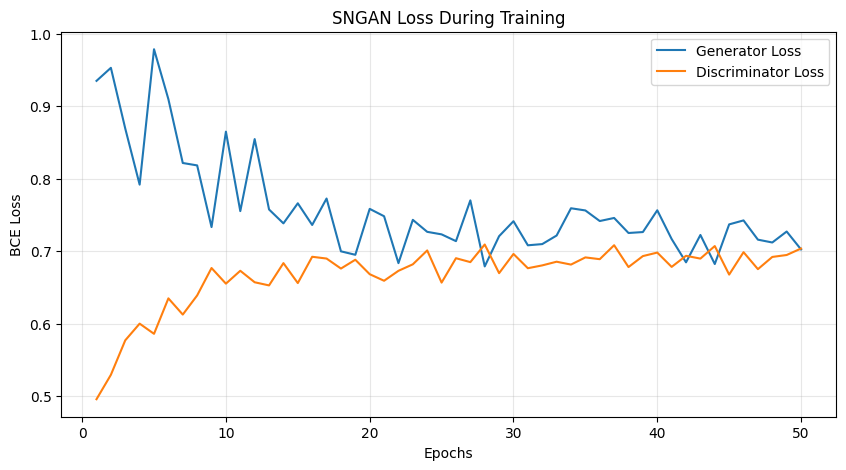

In [1]:

import matplotlib.pyplot as plt
import pandas as pd

# Define file paths
loss_file = "sngan.csv"
output_plot = "sngan_loss_plot.png"

print(f"Attempting to plot from {loss_file}...")

try:
    # Read the data from the CSV file using pandas
    df = pd.read_csv(loss_file)

    # Create the plot
    plt.figure(figsize=(10, 5))
    plt.plot(df["Epoch"], df["Generator_Loss"], label="Generator Loss")
    plt.plot(df["Epoch"], df["Discriminator_Loss"], label="Discriminator Loss")
    
    plt.title("SNGAN Loss During Training")
    plt.xlabel("Epochs")
    plt.ylabel("BCE Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Save the plot to a file
    plt.savefig(output_plot)
    print(f"Plot saved successfully to {output_plot}")

except FileNotFoundError:
    print(f"Error: The file '{loss_file}' was not found. Please make sure training is complete.")
except Exception as e:
    print(f"An error occurred: {e}")

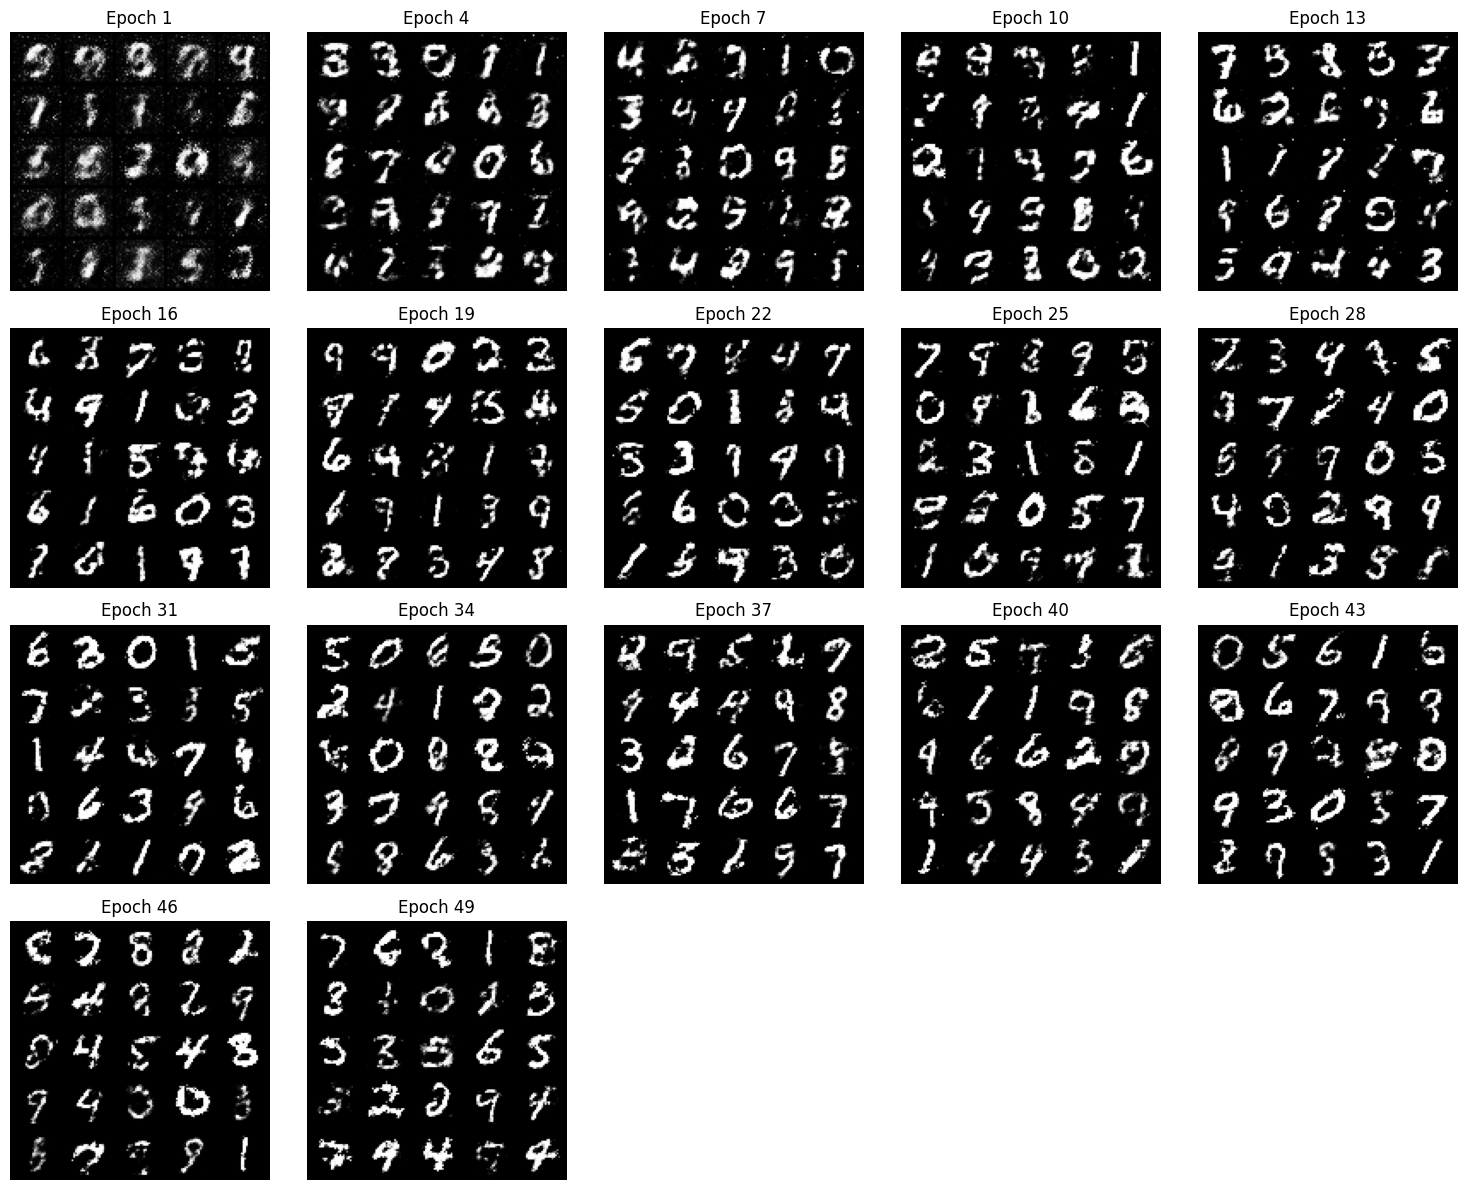

In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

folder = "images_sngan"
epochs = 50
step = 3

# Collect epochs to display
selected_epochs = list(range(1, epochs+1, step))

# Calculate grid size
cols = 5  # number of images per row
rows = (len(selected_epochs) + cols - 1) // cols

# Prepare the figure
fig, axes = plt.subplots(rows, cols, figsize=(15, rows*3))

for idx, epoch in enumerate(selected_epochs):
    r = idx // cols
    c = idx % cols
    ax = axes[r, c] if rows > 1 else axes[c]

    img_path = os.path.join(folder, f"{epoch}.png")
    if os.path.exists(img_path):
        img = mpimg.imread(img_path)
        ax.imshow(img)
        ax.set_title(f"Epoch {epoch}")
    ax.axis('off')

# Turn off any empty subplots
for i in range(len(selected_epochs), rows*cols):
    r = i // cols
    c = i % cols
    ax = axes[r, c] if rows > 1 else axes[c]
    ax.axis('off')

plt.tight_layout()
plt.savefig("wgan_progress_every5.png")
plt.show()